## Volve Field Notebook 4: What Happened to F-12 H?

In the water cut chart from Notebook 2, one line does something no other line does.
F-12 H sits at 97% water cut for years, then in early 2015 it falls off a cliff
down to about 30%, and climbs back up over the following year.

A reservoir does not un-flood itself, hence wather cut doesnt fall on its own.
Something was done to that well.

This notebook finds out what, **but** works out what the production data can and cannot prove.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/volve_daily_clean.csv", parse_dates=["Date"])
df["Well"] = df["Well"].str.replace("NO 15/9-", "", regex=False)

# Full days only, same reason as Notebook 2
full_days = df[df["On Stream Hours"] >= 23]

# Keep F-12 H unfiltered as the zero-hour rows ARE the shut-in evidence
f12_all = df[df["Well"] == "F-12 H"].sort_values("Date")
f12 = full_days[full_days["Well"] == "F-12 H"].sort_values("Date")

f12_all.shape, f12.shape

((3056, 28), (2545, 28))

In [5]:
# Zoom to daily rows around the drop to show the shut in and the recovery. The charts smooth things and raw rows do not.

window = f12_all[(f12_all["Date"] >= "2014-11-22") & (f12_all["Date"] <= "2015-01-04")]

window[["Date", "On Stream Hours", "Oil", "Water", "Water Cut", "Choke Size", "Wellhead Pressure"]]

,Date,On Stream Hours,Oil,Water,Water Cut,Choke Size,Wellhead Pressure
4301,2014-11-22,24.00000,182.72,4716.01,0.962701,100.000000,32.224279
4302,2014-11-23,24.00000,176.44,4709.50,0.963888,100.000000,31.888830
4303,2014-11-24,8.94167,50.87,1376.43,0.964359,36.976535,32.500626
4304,2014-11-25,0.00000,0.00,0.00,NaN,1.205265,20.693100
4305,2014-11-26,0.00000,0.00,0.00,NaN,0.963076,31.623140
4306,2014-11-27,0.00000,0.00,0.00,NaN,0.739278,19.097030
4307,2014-11-28,5.77500,58.69,836.01,0.934403,30.868756,50.511461
4308,2014-11-29,14.22500,146.09,828.47,0.850096,16.577640,83.154078
4309,2014-11-30,0.00000,0.00,0.00,NaN,1.006596,127.709810
4310,2014-12-01,0.00000,0.00,0.00,NaN,0.995805,130.912000


Three things seen from the data:

1. The well **stops**. Counting from 24 November 2014 to 1 January 2015. 0 on-stream hours on 35 of 38 days.
    with a brief flow on 28–29 November. The continuous shut-in runs 30 November to 31 December.
2. While it is shut in, **wellhead pressure builds** (83-124 bar), holding near 136 bar through December.
     Shows pressure equalises in a closed well.
3. When back on it produces **782 Sm³ oil and 226 Sm³ of water** against 176 Sm³ of oil and 4,710 Sm³ of water (November 22, 2014)
    on its last full day before the stop.

In [6]:
# Compare the 3 weeks before the shut-in with 1 month after it.

before = f12[(f12["Date"] >= "2014-11-01") & (f12["Date"] <= "2014-11-23")]
after  = f12[(f12["Date"] >= "2015-01-02") & (f12["Date"] <= "2015-01-31")]

print("F-12 H BEFORE the shut-in")
print("  oil       ", round(before["Oil"].mean()), "Sm3/day")
print("  water cut ", round(before["Water Cut"].mean() * 100, 1), "%")
print("  choke     ", round(before["Choke Size"].mean()), "%")

print("F-12 H AFTER the shut-in")
print("  oil       ", round(after["Oil"].mean()), "Sm3/day")
print("  water cut ", round(after["Water Cut"].mean() * 100, 1), "%")
print("  choke     ", round(after["Choke Size"].mean()), "%")

F-12 H BEFORE the shut-in
  oil        184 Sm3/day
  water cut  96.3 %
  choke      100 %
F-12 H AFTER the shut-in
  oil        874 Sm3/day
  water cut  30.0 %
  choke      31 %


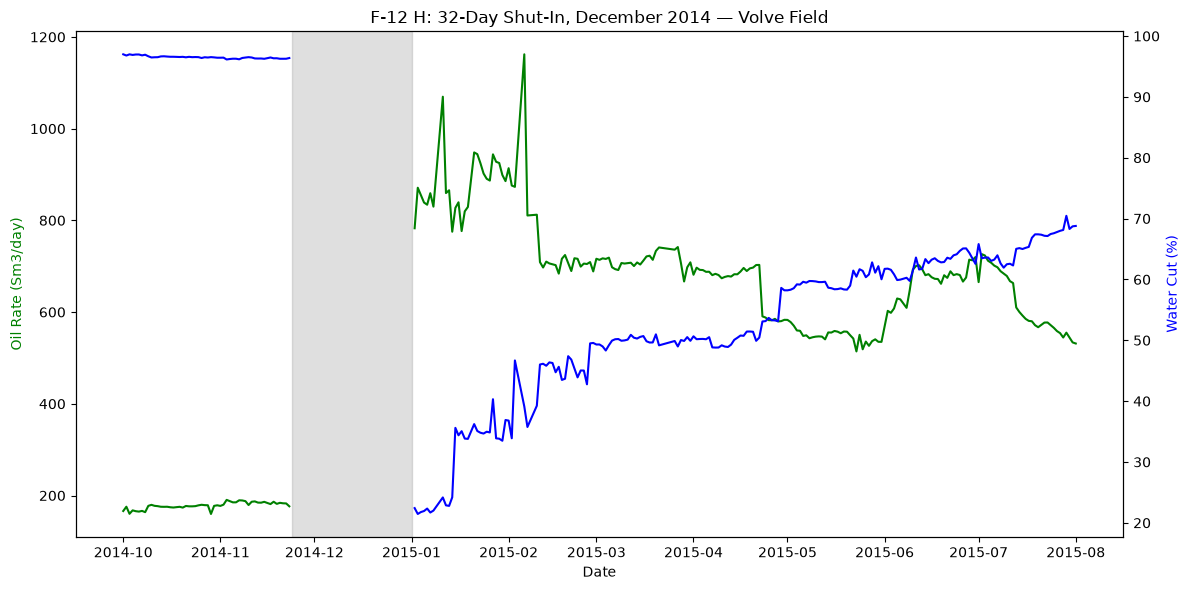

In [ ]:
# plot it, Oil rate on the left axis, water cut on the right, with the shut-in shaded.

plot_data = f12[(f12["Date"] >= "2014-10-01") & (f12["Date"] <= "2015-08-01")]

plot_data = plot_data[plot_data["On Stream Hours"] >= 23]   # full days only

fig, ax1 = plt.subplots(figsize=(12, 6))

before_plot = plot_data[plot_data["Date"] < "2014-11-24"] #split the line at the gap
after_plot  = plot_data[plot_data["Date"] > "2015-01-01"]

ax1.plot(before_plot["Date"], before_plot["Oil Rate"], color="green", label="Oil Rate")
ax1.plot(after_plot["Date"],  after_plot["Oil Rate"],  color="green", label="Oil Rate")

#ax1.plot(plot_data["Date"], plot_data["Oil Rate"], color="green", label="Oil Rate") # continuous line?

ax1.set_ylabel("Oil Rate (Sm3/day)", color="green")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(before_plot["Date"], before_plot["Water Cut"] * 100, color="blue", label="Water Cut")
ax2.plot(after_plot["Date"],  after_plot["Water Cut"] * 100,  color="blue", label="Water Cut")

#ax2.plot(plot_data["Date"], plot_data["Water Cut"] * 100, color="blue", label="Water Cut") # continuous line?
ax2.set_ylabel("Water Cut (%)", color="blue")

ax1.axvspan(pd.Timestamp("2014-11-24"), pd.Timestamp("2015-01-01"),
            color="grey", alpha=0.25)

plt.title("F-12 H: 32-Day Shut-In, December 2014 — Volve Field")
fig.tight_layout()
plt.savefig("../images/f12-intervention.png", dpi=350)
plt.show()

In [ ]:
# Check the producer F-14 H full days to answer did the reservoir change

f14 = full_days[full_days["Well"] == "F-14 H"].sort_values("Date")

f14_before = f14[(f14["Date"] >= "2014-11-01") & (f14["Date"] <= "2014-11-23")]
f14_after  = f14[(f14["Date"] >= "2015-01-02") & (f14["Date"] <= "2015-01-31")]

print("F-14 H water cut before:", round(f14_before["Water Cut"].mean() * 100, 1), "%")
print("F-14 H water cut after: ", round(f14_after["Water Cut"].mean() * 100, 1), "%")

# F-14 H water cut before: 0.0 %
# F-14 H water cut after:  0.0 %

F-14 H water cut before: 91.3 %
F-14 H water cut after:  91.3 %


In [ ]:
# In 2012 for F-12 H, 44-day shut-in, August 2012.
# Compare the 12 days before the shut-in with 20 days after it.

before_2012 = f12[(f12["Date"] >= "2012-08-01") & (f12["Date"] <= "2012-08-12")]
after_2012  = f12[(f12["Date"] >= "2012-09-30") & (f12["Date"] <= "2012-10-20")]

print("2012, 44-day shut-in")
print("  water cut before:", round(before_2012["Water Cut"].mean() * 100, 1), "%")
print("  water cut after: ", round(after_2012["Water Cut"].mean() * 100, 1), "%")

2012, 44-day shut-in
  water cut before: 86.8 %
  water cut after:  85.5 %


## Conclusion: F-12 H 

1. F-12 H was shut in for most of December 2014. It came back producing 874 Sm³/d of oil at 30% water cut, and 31% choke opening (mostly closed),
having gone off at 184 Sm³/d and 96% water cut and 100% choke opened. 

2. Nothing in the reservoir explains a well producing more oil through a valve that is mostly closed.
 F-14 H's water cut did not move at all over the same weeks.
 
3. longer shut-in on same F-12 H in 2012 changed nothing. 
 
4. Work was done on the wellbore. But the production data cannot say which job.